In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
data = pd.read_csv("cars.csv")

In [3]:
df = pd.DataFrame(data)

In [4]:
categorical_feature = df.select_dtypes(exclude=[np.number])
numerical_feature = df.select_dtypes(include=[np.number])

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_feature),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_feature)
    ])

In [6]:
corr_matrix = df.corr(numeric_only=True)

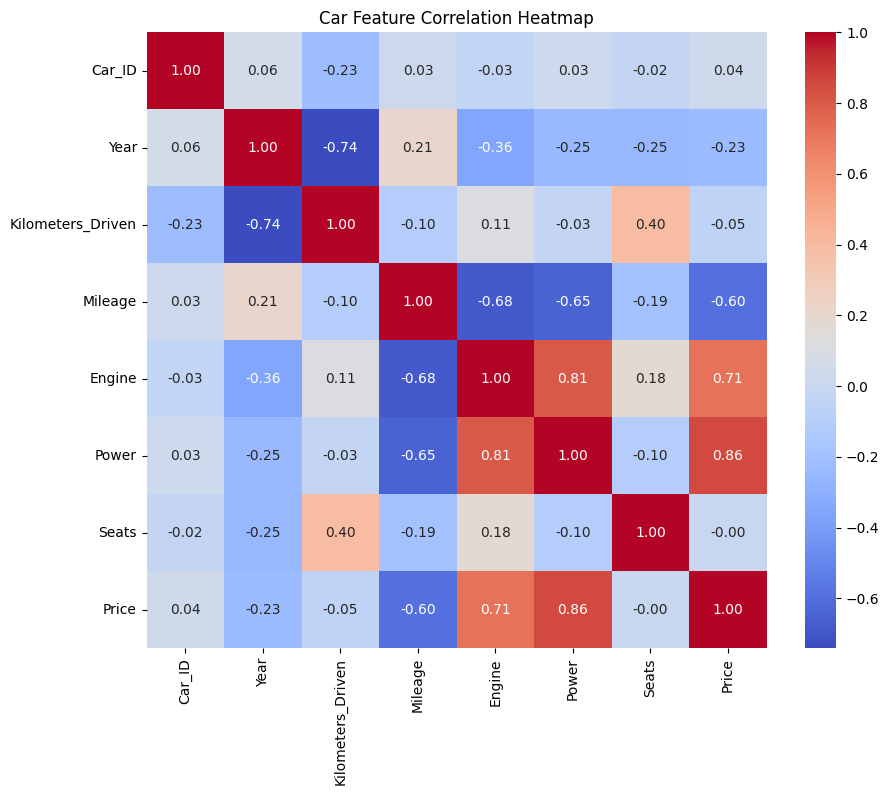

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Car Feature Correlation Heatmap")
plt.show()

In [8]:
target_corr = corr_matrix['Price'].abs()
relevant_features = target_corr[target_corr > 0.2].index.tolist()

print(f"Selected Features: {relevant_features}")

Selected Features: ['Year', 'Mileage', 'Engine', 'Power', 'Price']


In [9]:
fixed_df = df[relevant_features]

In [10]:
X = fixed_df.drop('Price', axis=1)
y = fixed_df['Price']

In [11]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()

y_2d = y.values.reshape(-1, 1)
y_scaled = scaler_y.fit_transform(y_2d)

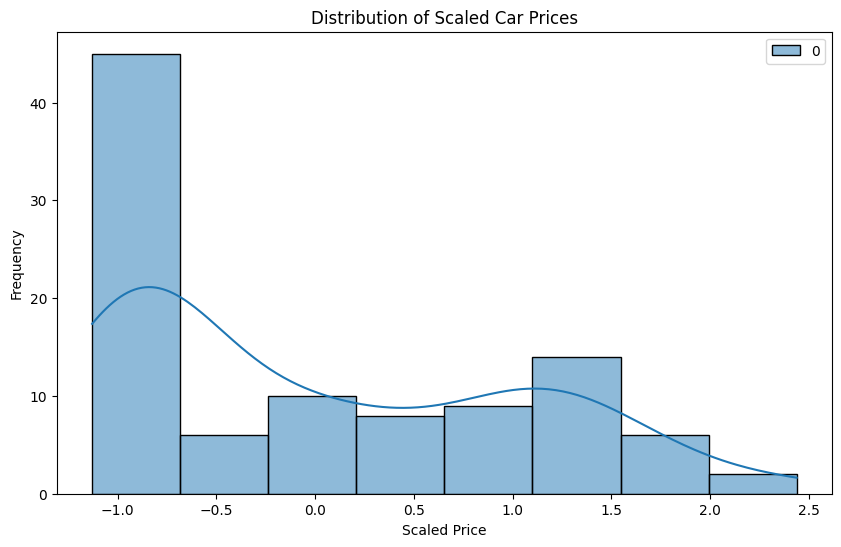

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(y_scaled, kde=True, color='blue')
plt.title('Distribution of Scaled Car Prices')
plt.xlabel('Scaled Price')
plt.ylabel('Frequency')
plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

I0000 00:00:1774102878.774865  380851 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774102878.775631  380851 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774102878.809425  380851 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774102879.593866  380851 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - loss: 1.1282 - mae: 0.9435 - val_loss: 0.6884 - val_mae: 0.7842
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1.0241 - mae: 0.9019 - val_loss: 0.6183 - val_mae: 0.7430
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.9437 - mae: 0.8633 - val_loss: 0.5586 - val_mae: 0.7039
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.8718 - mae: 0.8305 - val_loss: 0.5047 - val_mae: 0.6643
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.7968 - mae: 0.7943 - val_loss: 0.4558 - val_mae: 0.6244
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.7344 - mae: 0.7606 - val_loss: 0.4095 - val_mae: 0.5969
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.6742 - mae: 0.7266 - val_loss: 0.3675 - val_mae: 0.5718
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.6111 - mae: 0.6883 - val_loss: 0.3316 - val_mae: 0.5453
Epoch 9/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.5620 - mae:

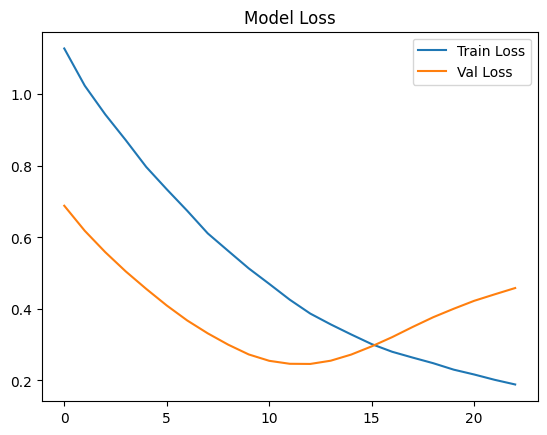

In [14]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

model = tf.keras.Sequential([
    layers.Input(shape=(X_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

scaled_predictions = model.predict(X_test)
final_predictions = scaler_y.inverse_transform(scaled_predictions)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


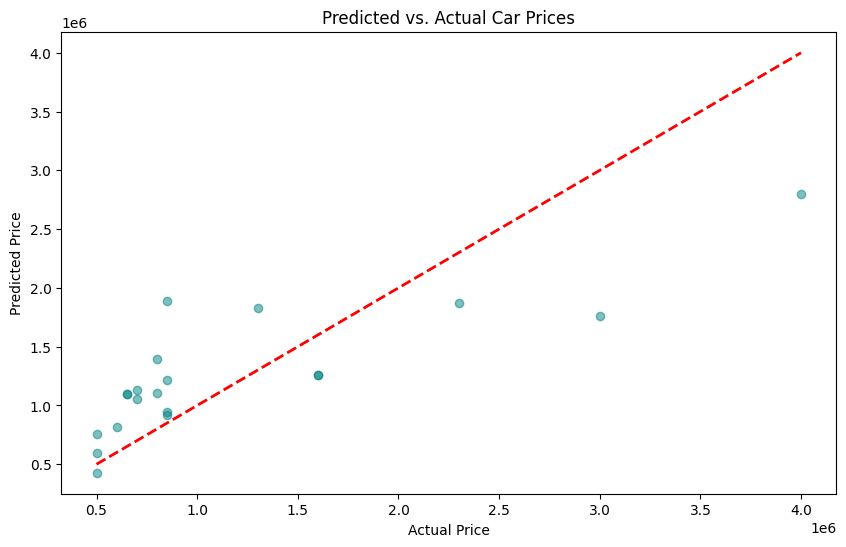

In [15]:
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_actual, y_pred, alpha=0.5, color='teal')
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
plt.title('Predicted vs. Actual Car Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

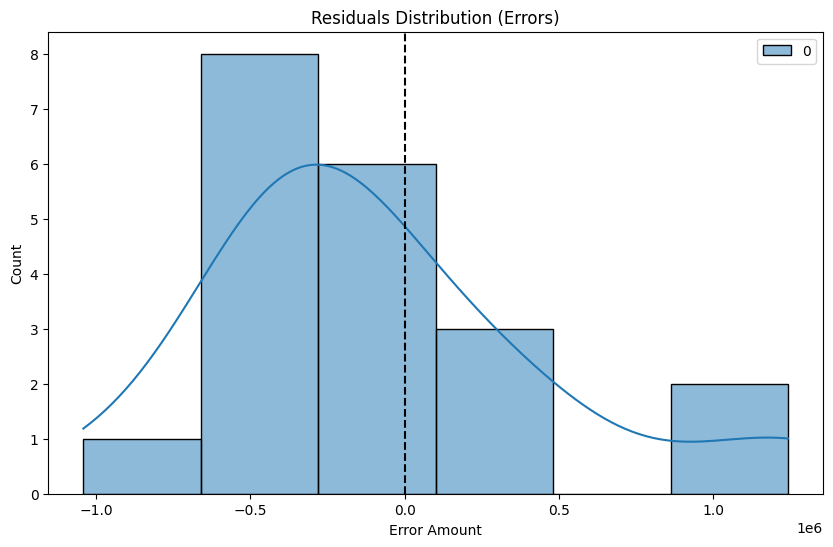

In [16]:
residuals = y_actual - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='crimson')
plt.axvline(0, color='black', linestyle='--')
plt.title('Residuals Distribution (Errors)')
plt.xlabel('Error Amount')
plt.show()

In [17]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_actual, y_pred)
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

R² Score: 0.6211
Mean Absolute Error: 444026.25
Root Mean Squared Error: 556690.80
